# Collective escape

Each fish is baseline (`spin = 0`) or escaping (`spin = 1`). Only `n_exposed` fish receive the threat pulse. Available fish activate with probability $1/[1+\exp(-h/T)]$, where $h$ combines the direct stimulus, social input from the escaping fraction, and the threshold. Visit available fish in random order so later fish see earlier activations.

Escapes last `escape_duration` steps. After recovery, fish remain at baseline for a fixed `refractory_duration` before becoming eligible again. Refractory fish contribute no social input and receive no activation attempts. Newly assigned timers are first decremented on the following step; a fish whose refractory timer expires becomes eligible on the next step.

All fish start at baseline. Run cells in order to reset the seeded simulation. Each history column records the state after one update, including column 0.

In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np

from agent import Agent
from stimulus import square_wave


In [14]:
# Simulation parameters
n_fish = 20
total_timesteps = 200
random_seed = 2026
n_exposed = 5

# Agent parameters
J = 1.
T = 0.1
threshold = 0.5
escape_duration = 5
refractory_duration = 10

# Stimulus parameters
stimulus_start = 10
stimulus_strength = 1
stimulus_duration = 5


In [15]:
# Initialise n_fish number of agents
rng = np.random.default_rng(random_seed)
agents = np.array([Agent() for _ in range(n_fish)])
for agent in agents:
    agent.spin = 0

# Select a fixed subset that receives the direct stimulus
exposed = np.zeros(n_fish, dtype=bool)
exposed[rng.choice(n_fish, size=n_exposed, replace=False)] = True


In [16]:
# Create stimulus and state history arrays
time = np.arange(total_timesteps)
stimulus = square_wave(time - stimulus_start, stimulus_strength, stimulus_duration)
state_history = np.empty((n_fish, len(time)), dtype=np.int8)
state_history[:, 0] = [agent.spin for agent in agents]


In [17]:
# Run the simulation
for t in range(total_timesteps):
    already_escaping = np.array([agent.spin == 1 for agent in agents])
    already_refractory = np.array([agent.refractory_timer > 0 for agent in agents])
    eligible = ~(already_escaping | already_refractory)
    active_count = int(already_escaping.sum())

    # Random sequential updates: the field changes after each new escape
    for fish in rng.permutation(np.flatnonzero(eligible)):
        activity = active_count / n_fish

        # Only exposed fish receive the external threat pulse
        direct_stimulus = stimulus[t] if exposed[fish] else 0.0
        field = direct_stimulus + J * activity - threshold
        
        probability = 1 / (1 + np.exp(-field / T))
        if rng.random() < probability:
            agents[fish].spin = 1
            agents[fish].recovery_timer = escape_duration
            active_count += 1

    # Advance existing refractory timers before assigning newly recovered fish
    for fish in np.flatnonzero(already_refractory):
        agents[fish].refractory_timer -= 1

    for fish in np.flatnonzero(already_escaping):
        agents[fish].recovery_timer -= 1
        if agents[fish].recovery_timer == 0:
            agents[fish].spin = 0
            agents[fish].refractory_timer = refractory_duration

    state_history[:, t] = [agent.spin for agent in agents]


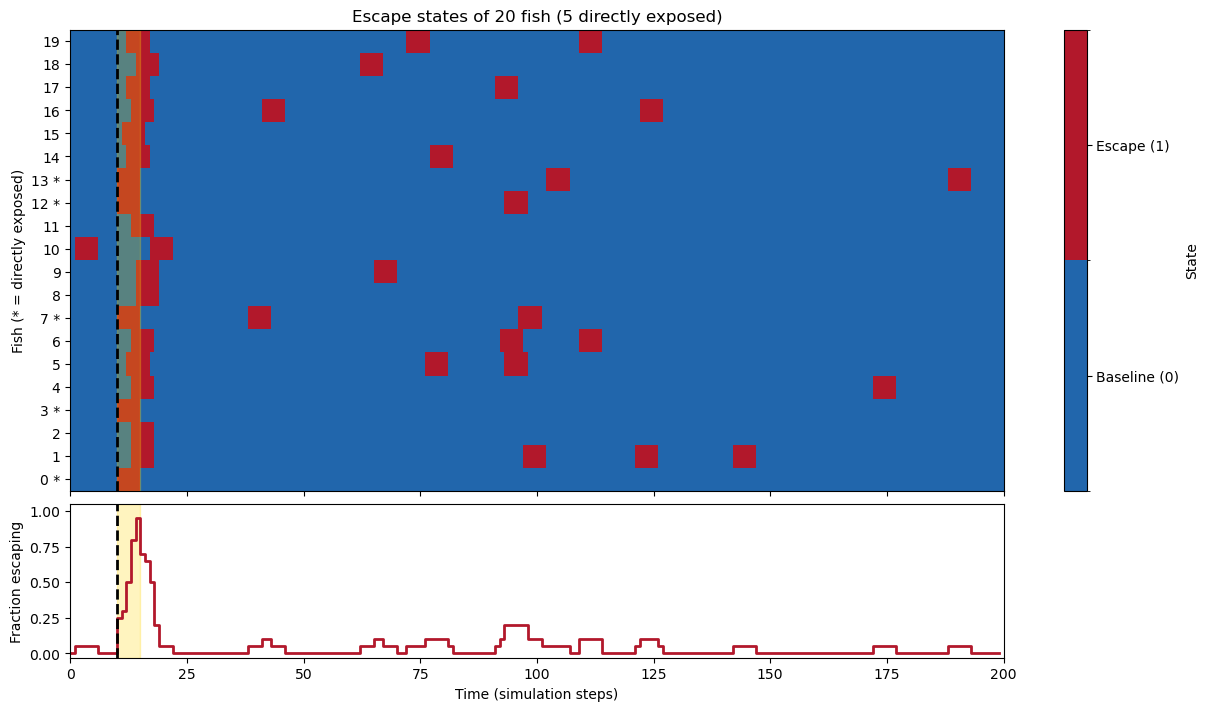

In [18]:
escape_fraction = state_history.mean(axis=0)

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]})
cmap = ListedColormap(["#2166ac", "#b2182b"])
image = ax1.pcolormesh(np.arange(total_timesteps + 1), np.arange(n_fish + 1) - 0.5,
                       state_history, cmap=cmap, norm=BoundaryNorm([-0.5, 0.5, 1.5], cmap.N))

ax1.set_yticks(np.arange(n_fish))
ax1.set_yticklabels([f"{i} *" if exposed[i] else str(i) for i in range(n_fish)])
ax1.set_ylabel("Fish (* = directly exposed)")
ax1.set_title(f"Escape states of {n_fish} fish ({n_exposed} directly exposed)")
colorbar = fig.colorbar(image, ax=ax1, ticks=[0, 1], label="State")
colorbar.ax.set_yticklabels(["Baseline (0)", "Escape (1)"])

ax2.step(time, escape_fraction, where="post", color="#b2182b", linewidth=2, label="Escaping")
ax2.set_ylim(-0.03, 1.05)
ax2.set_ylabel("Fraction escaping")
ax2.set_xlabel("Time (simulation steps)")

for panel in (ax1,ax2):
    panel.axvspan(stimulus_start, stimulus_start + stimulus_duration, color="gold", alpha=0.25)
    panel.axvline(stimulus_start, color="black", linestyle="--", linewidth=2)
plt.show()
